# AGS - Ejercicio

Maximizar la función:

$$f(x) = \left[1 - \left(\frac{11}{2}x - \frac{7}{2}\right)^2\right]\left[\cos\left(\frac{11}{2}x - \frac{7}{2}\right) + 1\right] + 2$$

Con $x \in [0, 0.875]$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Parámetros del AGS

In [2]:
Nind = 5
Lind = 20
Pc = 0.70
Pm = 1/15
Maxgen = 100
Nvar = 1
rango = np.array([[0, 0.875]])

## 2. Funciones del AGS

In [3]:
def objfun(fenotipo):
    Nind, Nvar = fenotipo.shape
    objv = np.zeros((Nind, 1))
    for i in range(Nind):
        u = (11/2) * fenotipo[i, 0] - 7/2
        objv[i, 0] = (1 - u**2) * (np.cos(u) + 1) + 2
    return objv

In [4]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))

In [5]:
def decodifica(genotipo, rango):
    Nvar = rango.shape[0]
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar
    potencias = 2 ** np.arange(Lvar)
    fenotipo = np.zeros((Nind, Nvar))
    for i in range(Nind):
        for j in range(Nvar):
            fenotipo[i, j] = np.sum(potencias * genotipo[i, (j * Lvar):(j * Lvar + Lvar)])
    for i in range(Nvar):
        fenotipo[:, i] = rango[i, 0] + ((rango[i, 1] - rango[i, 0]) / (2 ** Lvar - 1)) * fenotipo[:, i]
    return fenotipo

In [6]:
def rankeo(objv, direccion):
    SP = 2
    Nind, Nobj = objv.shape
    aptitud = np.zeros((Nind, 1))
    if direccion == 1:
        nuevo_objv = np.sort(objv, axis=0)
    else:
        nuevo_objv = np.sort(-1 * objv, axis=0)
    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    posori = np.argsort(objv, axis=0).flatten()
    aptitud[posori, 0] = apt
    return aptitud

In [7]:
def ruleta(genotipo, fenotipo, aptitud):
    Nind, aux = aptitud.shape
    total = np.sum(aptitud)
    probabilidad = aptitud / total
    acumulada = np.cumsum(probabilidad)
    idx = np.zeros((Nind, 1), dtype=int)
    for i in range(Nind):
        selecciona = np.random.rand()
        aux = np.where(acumulada >= selecciona)[0]
        idx[i, 0] = aux[0]
    nuevo_gen = genotipo[idx.flatten(), :]
    return nuevo_gen

In [8]:
def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = np.zeros((Nind, Lind))
    par = Nind % 2
    for i in range(0, Nind - 1, 2):
        cruza = np.random.rand()
        if cruza <= Pc:
            corte = np.random.randint(0, Lind - 1)
            aux_gen[i, :] = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i + 1, corte:]))
            aux_gen[i + 1, :] = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:]))
        else:
            aux_gen[i, :] = nuevo_gen[i, :]
            aux_gen[i + 1, :] = nuevo_gen[i + 1, :]
    if par == 1:
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :]
    nuevo_gen = aux_gen
    return nuevo_gen

In [9]:
def muta(nuevo_gen, Pm):
    Nind, Lind = nuevo_gen.shape
    valores = np.random.rand(Nind, Lind)
    mutaciones = valores <= Pm
    nuevo_gen = np.logical_xor(nuevo_gen, mutaciones).astype(int)
    return nuevo_gen

## 3. Crear la población inicial

In [10]:
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)
objv = objfun(fenotipo)

Mejor = np.full((Maxgen, 1), np.nan)
Mejor_cromosoma = np.zeros((Maxgen, Lind))

## 4. Ciclo Evolutivo

In [11]:
generaciones = 0
while generaciones < Maxgen:
    aptitud = rankeo(objv, 1)
    nuevo_gen = ruleta(genotipo, fenotipo, aptitud)
    nuevo_gen = xunpunto(nuevo_gen, Pc)
    nuevo_gen = muta(nuevo_gen, Pm)
    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun(nuevo_feno)
    genotipo = nuevo_gen
    fenotipo = nuevo_feno
    objv = nuevo_objv
    idx = np.argmax(objv)
    Mejor[generaciones] = objv[idx]
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]
    generaciones += 1

## 5. Resultados

In [12]:
mejor_idx = np.nanargmax(Mejor)
mejor_valor = Mejor[mejor_idx, 0]
mejor_crom = Mejor_cromosoma[mejor_idx, :]
mejor_feno = decodifica(mejor_crom.reshape(1, -1), rango)

print(f"Mejor valor encontrado: {mejor_valor:.6f}")
print(f"En x = {mejor_feno[0, 0]:.6f}")
print(f"Generacion: {mejor_idx}")

Mejor valor encontrado: 3.970136
En x = 0.656261
Generacion: 76


## 6. Gráfica de convergencia

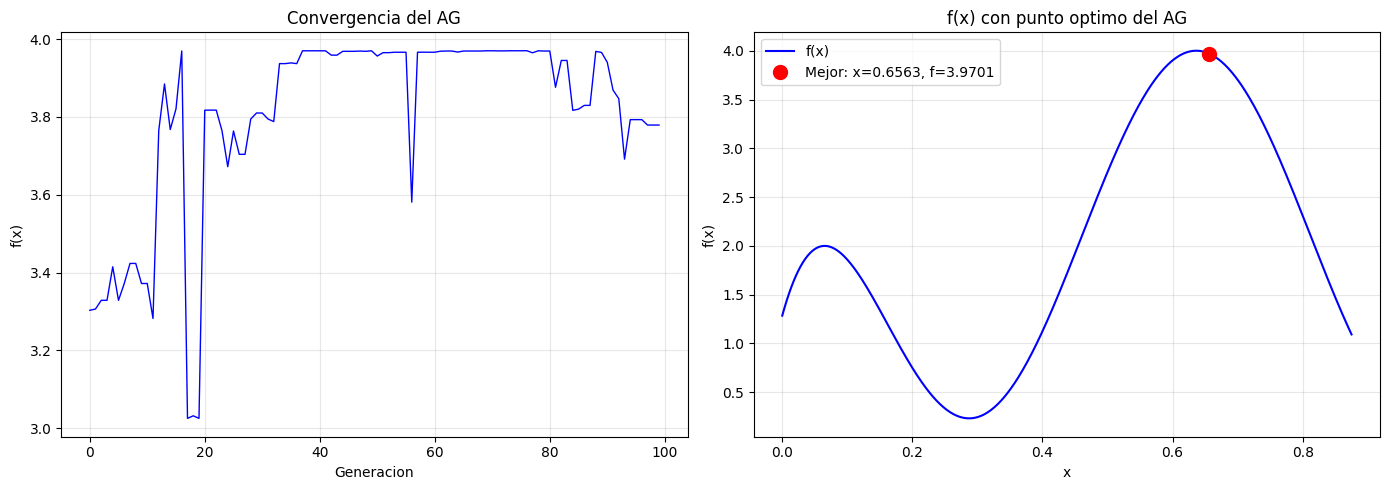

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(Maxgen), Mejor, 'b-', linewidth=1)
axes[0].set_xlabel('Generacion')
axes[0].set_ylabel('f(x)')
axes[0].set_title('Convergencia del AG')
axes[0].grid(True, alpha=0.3)

x_vals = np.linspace(0, 0.875, 500)
u_vals = (11/2) * x_vals - 7/2
y_vals = (1 - u_vals**2) * (np.cos(u_vals) + 1) + 2

axes[1].plot(x_vals, y_vals, 'b-', linewidth=1.5, label='f(x)')
axes[1].plot(mejor_feno[0, 0], mejor_valor, 'ro', markersize=10, label=f'Mejor: x={mejor_feno[0,0]:.4f}, f={mejor_valor:.4f}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('f(x) con punto optimo del AG')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Comparación con búsqueda exhaustiva (sin AG)

Busqueda exhaustiva (sin AG):
Mejor valor: 4.000000
En x = 0.636364


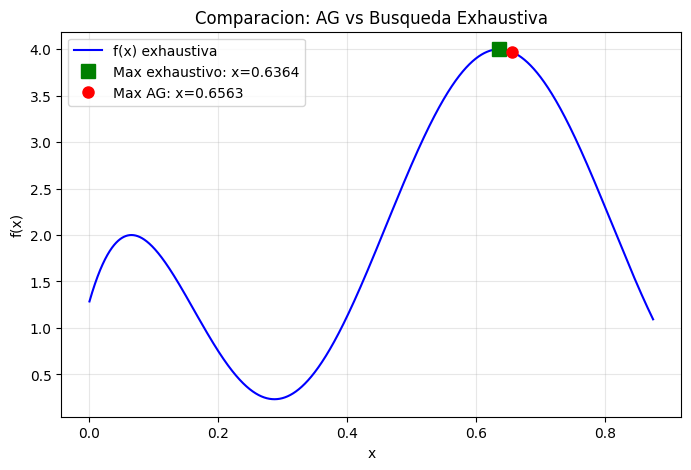

In [14]:
x_grid = np.linspace(0, 0.875, 10000)
u_grid = (11/2) * x_grid - 7/2
f_grid = (1 - u_grid**2) * (np.cos(u_grid) + 1) + 2
idx_max = np.argmax(f_grid)

print(f"Busqueda exhaustiva (sin AG):")
print(f"Mejor valor: {f_grid[idx_max]:.6f}")
print(f"En x = {x_grid[idx_max]:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(x_grid, f_grid, 'b-', linewidth=1.5, label='f(x) exhaustiva')
plt.plot(x_grid[idx_max], f_grid[idx_max], 'gs', markersize=10, label=f'Max exhaustivo: x={x_grid[idx_max]:.4f}')
plt.plot(mejor_feno[0, 0], mejor_valor, 'ro', markersize=8, label=f'Max AG: x={mejor_feno[0,0]:.4f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Comparacion: AG vs Busqueda Exhaustiva')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()